In [1]:
# Install required libraries
!pip install tensorflow matplotlib scikit-learn

# Imports
from tensorflow.keras.datasets import fashion_mnist

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Conv2D,
    Flatten,
    MaxPooling2D,
    Dropout
)

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(x_train.shape)
print(x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(10000, 28, 28)


In [3]:
# Class names
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [4]:
# Reshape and normalize
x_train = x_train.reshape((-1,28,28,1)) / 255.0
x_test = x_test.reshape((-1,28,28,1)) / 255.0

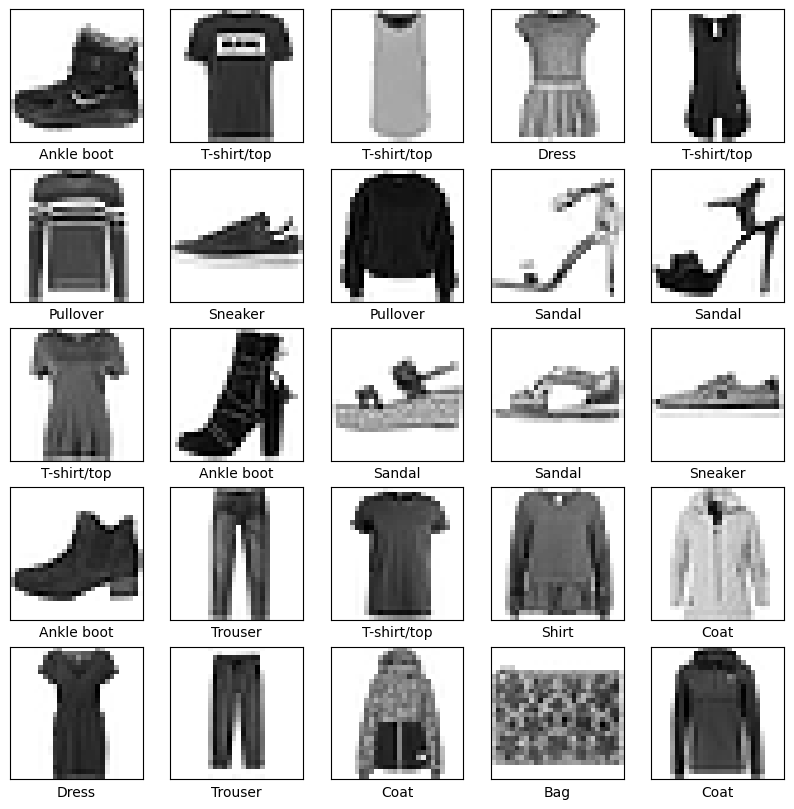

In [5]:
# Show images
plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(x_train[i], cmap=plt.cm.binary)

    plt.xlabel(class_names[y_train[i]])

plt.show()

In [6]:
# Build CNN model
model = Sequential()

model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(units=32, activation='relu'))

model.add(Dense(units=10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Compile model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [8]:
# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       346,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,114 (1.32 MB)

 Trainable params: 347,114 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Train
model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=1200,
    validation_split=0.05
)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7300 - loss: 0.8422 - val_accuracy: 0.8153 - val_loss: 0.5092
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8372 - loss: 0.4659 - val_accuracy: 0.8507 - val_loss: 0.4078
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8578 - loss: 0.4072 - val_accuracy: 0.8667 - val_loss: 0.3670
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8711 - loss: 0.3746 - val_accuracy: 0.8837 - val_loss: 0.3397
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8774 - loss: 0.3530 - val_accuracy: 0.8890 - val_loss: 0.3261
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8838 - loss: 0.3370 - val_accuracy: 0.8880 - val_loss: 0.3267
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.8870 - loss: 0.3256 - val_accuracy: 0.8977 - val_loss: 0.2997
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8926 - loss: 0.3080 - val_accuracy: 0.8987 - val_loss:

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8900 - loss: 0.3083
Accuracy: 0.8899999856948853
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
[9 2 1 ... 8 1 5]


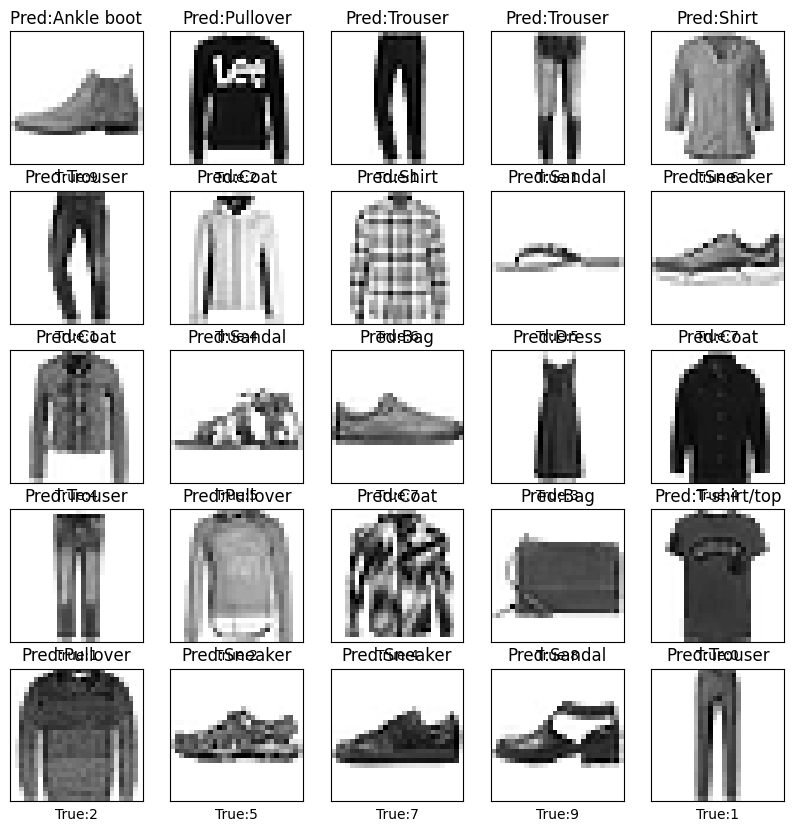

In [10]:
# Evaluate
evaluation = model.evaluate(x_test, y_test)

print("Accuracy:", evaluation[1])

# Predictions
y_probas = model.predict(x_test)

y_pred = y_probas.argmax(axis=-1)

print(y_pred)

# Show predictions
plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(x_test[i], cmap=plt.cm.binary)

    plt.xlabel(f"True:{y_test[i]}")

    plt.title(f"Pred:{class_names[y_pred[i]]}")

plt.show()

In [11]:
# Classification report
from sklearn.metrics import classification_report

num_classes = 10

class_names = ['class {}'.format(i) for i in range(num_classes)]

cr = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print(cr)

              precision    recall  f1-score   support

     class 0       0.82      0.86      0.84      1000
     class 1       0.99      0.97      0.98      1000
     class 2       0.81      0.84      0.82      1000
     class 3       0.87      0.92      0.89      1000
     class 4       0.84      0.81      0.82      1000
     class 5       0.98      0.96      0.97      1000
     class 6       0.73      0.65      0.69      1000
     class 7       0.93      0.97      0.95      1000
     class 8       0.96      0.98      0.97      1000
     class 9       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

